In [1]:
from collections.abc import Iterable
from networkx.algorithms.approximation import steiner_tree
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import HeteroData
from torch_geometric.utils import to_networkx
from jazz_graph.data.graph_builder.make_jazz import JazzDataStore, make_jazz_graph, make_jazz_graph_with_style_and_edges
from jazz_graph.recommendation.recommender import LookupRecordings
from jazz_graph.data.fetch import fetch_recording_traits


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

graph_data = make_jazz_graph_with_style_and_edges(JazzDataStore('/workspace/local_data/graph_parquet'))
lookup = LookupRecordings.from_hetero_data(graph_data)
recording_traits = fetch_recording_traits().set_index('recording_id')

/workspace/src/jazz_graph/data/fetch.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params={'start': start, 'end': end})


## Visualize

In [3]:
graph_data

HeteroData(
  performance={
    x=[130695, 2],
    album_id=[130695],
    style=[130695, 20],
  },
  artist={ x=[24470, 1] },
  song={ x=[31828, 1] },
  (artist, composed, song)={ edge_index=[2, 36252] },
  (artist, performs, performance)={
    edge_index=[2, 516713],
    edge_attr=[516713, 1],
  },
  (performance, performing, song)={ edge_index=[2, 86588] },
  (song, rev_composed, artist)={ edge_index=[2, 36252] },
  (performance, rev_performs, artist)={
    edge_index=[2, 516713],
    edge_attr=[516713, 1],
  },
  (song, rev_performing, performance)={ edge_index=[2, 86588] }
)

In [4]:
import itertools
# koln = recording_traits[recording_traits.album.str.contains('ln Concert') & recording_traits.artist.str.contains('Jarr')].index
inner_urge = recording_traits[recording_traits.album.str.contains('Urge') & recording_traits.artist.str.contains('Hend')].index
sunday_vangaurd = recording_traits.loc[[1662631, 696865, 159842, 159841, 12541732, 12541735]].index
speak_no_evil = recording_traits[recording_traits.album.str.contains('Speak No') & recording_traits.artist.str.contains('Short')][:6].index
blues_abstract = recording_traits[recording_traits.album.str.contains('The Blues') & recording_traits.artist.str.contains('Oliver')].index
all_examples = [x for x in itertools.chain(
    # koln,
    inner_urge, sunday_vangaurd, speak_no_evil, blues_abstract)]


In [5]:
import qrcode

li = 'https://www.linkedin.com/in/stephen-lenhart/'
qrcode.make(li).save('/workspace/documents/linkedin_qr.png')
playlist = 'https://open.spotify.com/playlist/5R3LBg4sgKA4aKWQ9GLm8P?si=fac6e9ceeb9641c1'
apple_music = 'https://music.apple.com/us/album/dusk-fire/1444853909'
qrcode.make(playlist).save('/workspace/documents/spotify_playlist.png')
qrcode.make(apple_music).save('/workspace/documents/apple_music_playlist.png')

In [6]:
print(all_examples)

[3427034, 14805308, 14805309, 14805310, 14805311, 1662631, 696865, 159842, 159841, 12541732, 12541735, 415771, 415772, 415774, 415775, 415777, 415779, 811575, 811576, 811577, 811578, 811579, 5748097]


In [7]:
md = """
|       |    composed |   performs |    performing |   rev_composed |   rev_performs |   rev_performing |
|:------|------------:|-----------:|--------------:|---------------:|---------------:|-----------------:|
| mean  |     1.48    |    21.11   |      0.66     |       1.13     |        3.95    |          2.72    |
| min   |     0       |     0      |      0        |       1        |        0       |          1       |
| 50%   |     0       |     8      |      1        |       1        |        3       |          1       |
| 75%   |     1       |    16      |      1        |       1        |        5       |          1       |
| 90%   |     3       |    44      |      1        |       1        |        8       |          4       |
| 97%   |    11       |   126      |      1        |       3        |       17       |         14       |
| max   |   288       |  1788      |     13        |       9        |       81       |        321       |
"""
def to_latex(md_table):
    import re
    lines = md_table.split('\n')

    def format_line(line):
        line = line.strip('|')
        line = line + '//'
        return re.sub(r'\|', '&&', line)

    return '\n'.join([format_line(line) for line in lines])

print(to_latex(md))


//
       &&    composed &&   performs &&    performing &&   rev_composed &&   rev_performs &&   rev_performing //
:------&&------------:&&-----------:&&--------------:&&---------------:&&---------------:&&-----------------://
 mean  &&     1.48    &&    21.11   &&      0.66     &&       1.13     &&        3.95    &&          2.72    //
 min   &&     0       &&     0      &&      0        &&       1        &&        0       &&          1       //
 50%   &&     0       &&     8      &&      1        &&       1        &&        3       &&          1       //
 75%   &&     1       &&    16      &&      1        &&       1        &&        5       &&          1       //
 90%   &&     3       &&    44      &&      1        &&       1        &&        8       &&          4       //
 97%   &&    11       &&   126      &&      1        &&       3        &&       17       &&         14       //
 max   &&   288       &&  1788      &&     13        &&       9        &&       81       &&        32

In [8]:
from torch_geometric.loader import NeighborLoader
all_node_idx = lookup.lookup_node_index(all_examples)
favorites = next(iter(NeighborLoader(graph_data, [10], batch_size=len(all_examples), input_nodes=('performance', all_node_idx))))

/opt/conda/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


In [9]:
JazzDataStore('/workspace/local_data/graph_parquet').load('artist_nodes.parquet')

,artist_id
0,17
1,23
2,29
3,32
4,42
...,...
24465,3112299
24466,3112480
24467,3112490
24468,3112543


In [10]:
pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [12]:
from jazz_graph.data.graph_transforms import map_to_new_node_index
from torch_geometric.utils import index_to_mask

def subgraph_heterogenous(graph: HeteroData, nodes: Iterable, node_type: str):
    dst_graph = HeteroData()
    source_nodes = torch.tensor(nodes)
    node_types, edge_types = graph.metadata()
    dst_graph[node_type].x = graph[node_type].x[source_nodes]
    edges_to_reinspect = set()
    global_ids = {}
    for edge_type in edge_types:
        if edge_type[0] == node_type:
            src_edge = 0
            dst_edge = 1
            dst_type = edge_type[-1]
        elif edge_type[-1] == node_type:
            src_edge = 1
            dst_edge = 0
            dst_type = edge_type[0]
        else:
            print(f"{edge_type} ignored")
            edges_to_reinspect.add(edge_type)
            continue
        edge_index = graph[edge_type].edge_index
        new_edge = edge_index[:, torch.isin(edge_index[src_edge], source_nodes)]
        new_nodes = torch.unique(new_edge[dst_edge])
        destination_ids = global_ids.get(dst_type)
        if destination_ids is None:
            global_ids[dst_type] = new_nodes
        else:
            destination_ids = torch.unique(torch.concat([destination_ids, new_nodes]))
        dst_graph[dst_type].x = graph[dst_type].x[new_nodes]
        if src_edge == 0:
            dst_graph[edge_type].edge_index = remap_edge(new_edge, source_nodes, new_nodes)
        else:
            dst_graph[edge_type].edge_index = remap_edge(new_edge, new_nodes, source_nodes)
    # add any artist-composed-song edges where the artist and song are both in the existing graph.
    for edge_type in edges_to_reinspect:
        edge_index = graph[edge_type].edge_index
        src_mask = torch.isin(edge_index[0], global_ids[edge_type[0]])
        dst_mask = torch.isin(edge_index[1], global_ids[edge_type[-1]])
        mask = src_mask & dst_mask
        dst_graph[edge_type].edge_index = remap_edge(edge_index[:, mask], edge_index[0][src_mask], edge_index[1][dst_mask])

    return dst_graph

def remap_edge(edge_index, src_nodes, dst_nodes):
    src_edge = _remap_edge(edge_index[0], src_nodes)
    dst_edge = _remap_edge(edge_index[1], dst_nodes)
    return torch.stack([src_edge, dst_edge])

def _remap_edge(edge, nodes):
    edge = edge.clone()
    mapping = {node.item(): i for i, node in enumerate(nodes)}
    for i in range(edge.size(0)):
        src_idx = edge[i].item()
        edge[i] = mapping[src_idx]
    return edge

# favorites = subgraph_heterogenous(graph_data, lookup.lookup_node_index(all_examples), 'performance')
# favorites.metadata()
# favorites['composed']

In [13]:
def subset_heterogeneous(graph):
    dst_graph = HeteroData()
    new_node_indecies: dict = build_node_indecies(graph, nodes, node_type)
    new_nodes = prune_nodes(graph, new_node_indecies)
    for edge_type in graph.edge_types:
        new_edge_index = remap_edge(edge_type, new_node_indecies)
        dst_graph[edge_type] = new_edge_index
    return dst_graph


In [15]:
class HeteroDataTraits:
    def __init__(self, recording_traits: pd.DataFrame, artist_traits: pd.DataFrame, song_traits: pd.DataFrame):
        self.traits = {
            'performance': recording_traits,
            'artist': artist_traits,
            'song': song_traits
        }

    def get_nodes_traits(self, hetero_data: HeteroData, node_type: str, ids: list[int] | np.ndarray[tuple[int]]):
        traits = self.get_traits(hetero_data, node_type)
        return traits.loc[ids]

    def node_ids_by_edge(
        self,
        hetero_data: HeteroData,
        edge_type: tuple,
        source_ids: list[int],
        source_type: str,
    ):
        """Return node ids from the opposite end of edges from the given nodes.

        Args:
            edge_type:   e.g. ('artist', 'performs', 'performance')
            node_ids:    local indexes of the source nodes
            source_type: node type of the inputs, e.g. 'artist' — determines
                         which end of the edge to match on
        """
        src_type, _, dst_type = edge_type
        if source_type == src_type:
            source_edge = 0
            target_type = dst_type
        elif source_type == dst_type:
            source_edge = 1
            target_type = src_type
        else:
            raise ValueError(f"source_type '{source_type}' not found in edge_type {edge_type}")

        edge_index = hetero_data[edge_type].edge_index
        # get the index corresponding to the source_ids.
        source_indexes = self.node_indexes(hetero_data, source_type, source_ids)
        # find the indexes in the target edge with the ids we want.
        mask = torch.isin(edge_index[source_edge], torch.tensor(source_indexes))
        target_idx = edge_index[1 - source_edge][mask]

        id_col = self._id_col(target_type)
        data = hetero_data[target_type].x[:, id_col]
        # preserve order by making a mask.
        target_mask = torch.isin(torch.arange(data.size(0)), target_idx)
        return data[target_mask].numpy()

    def get_linked_traits(
            self,
            hetero_data: HeteroData,
            edge_type: tuple,
            source_ids: list[int],
            source_type: str,
    ):
        target_node_ids = self.node_ids_by_edge(hetero_data, edge_type, source_ids, source_type)
        src_type, _, dst_type = edge_type
        target_type = dst_type if source_type == src_type else src_type
        # print(target_type, source_type, source_ids, target_node_ids)
        return self.get_nodes_traits(hetero_data, target_type, target_node_ids)

    def get_traits(self, hetero_data: HeteroData, node_type: str) -> pd.DataFrame:
        """Get data about node_type in hetero_data."""
        if node_type not in self.traits:
            raise ValueError(f"Unsupported node type: {node_type}")
        graph_data = hetero_data[node_type].x
        id_col = self._id_col(node_type)
        data = self.traits[node_type]
        ids = graph_data[:, id_col].numpy()
        return data.loc[ids]

    def node_indexes(self, hetero_data: HeteroData, node_type: str, node_ids: Iterable[int]) -> np.ndarray[tuple[int], np.dtype[np.int64]]:
        """Return the indexes for node_id values (recording_id, artist_id)."""
        data = hetero_data[node_type].x
        id_col = self._id_col(node_type)
        data = data[:, id_col]
        mask = torch.isin(data, torch.tensor(node_ids))
        return torch.arange(data.size(0))[mask].numpy()

    def _id_col(self, node_type: str):
        if node_type == 'artist':
            return 0
        if node_type == 'performance':
            return 1
        if node_type == 'song':
            return 0
        raise ValueError(f"Expected a node type in jazz data model. Got {node_type}")

class MakeLabels:
    def __init__(self, data_traits: HeteroDataTraits):
        self.data_traits = data_traits

    def _id_col(self, node_type: str):
        if node_type == 'artist':
            return 0
        if node_type == 'performance':
            return 1
        if node_type == 'song':
            return 0
        raise ValueError(f"Expected a node type in jazz data model. Got {node_type}")


    def label(self, hetero_data: HeteroData, node_index: int, node_type: str):
        if node_type not in {'artist', 'performance'}:
            return f"{node_type}_{node_index}"
        traits = self.data_traits.traits[node_type]
        col = self._id_col(node_type)
        node_id = hetero_data[node_type].x[node_index, col].item() # get node id
        node_info = traits.loc[node_id]
        if node_type == 'artist':
            return node_info['artist_name']
        if node_type == 'performance':
            return node_info['title']

    def performance_labels(self, hetero_data: HeteroData, recording_ids) -> dict:
        traits = self.data_traits.get_nodes_traits(hetero_data, 'performance', recording_ids)
        indices = self.data_traits.node_indexes(hetero_data, 'performance', recording_ids)
        # return {int(id): traits.iloc[i].title for i, id in enumerate(indices)}
        return {i: traits.iloc[i].title for i, id in enumerate(indices)}

    def artist_labels(self, hetero_data: HeteroData, artist_ids=None, recording_ids=None) -> dict:
        if artist_ids:
            traits = self.data_traits.get_nodes_traits(hetero_data, 'artist', artist_ids)
            indices = self.data_traits.node_indexes(hetero_data, 'artist', artist_ids)
        else:
            assert recording_ids is not None
            traits = self.data_traits.get_linked_traits(hetero_data, ('artist', 'performs', 'performance'), recording_ids, 'performance')
            indices = self.data_traits.node_ids_by_edge(hetero_data, ('artist', 'performs', 'performance'), recording_ids, 'performance')
        return {i: traits.iloc[i].artist_name for i, id in enumerate(indices)}
        return {int(id): traits.iloc[i].artist_name for i, id in enumerate(indices)}


In [16]:

from typing import Callable
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
from torch_geometric.data import HeteroData


# Visual config — tweak these to taste
NODE_COLORS = {
    "artist":      "#E8A838",   # warm amber
    "performance": "#4A90D9",   # blue
    "song":        "#5CB85C",   # green
}

EDGE_COLORS = {
    ("artist",      "performs",    "performance"): "#E8A838",
    ("performance", "performing",  "song"):        "#4A90D9",
    ("artist",      "composes",    "song"):        "#A855F7",
    # reverse edges get the same color as their forward counterpart
    ("performance", "performed_by", "artist"):     "#E8A838",
    ("song",        "performed_in", "performance"):"#4A90D9",
    ("song",        "composed_by",  "artist"):     "#A855F7",
}


def pyg_to_networkx(data: HeteroData, make_labels: MakeLabels, layout=True) -> tuple[nx.Graph, dict]:
    """
    Convert a PyG HeteroData object to a NetworkX graph.

    Args:
        data:         HeteroData object from your jazz GNN
        node_labels:  Optional dict of dicts, e.g.
                      {"artist": {0: "Joe Henderson"}, "performance": {0: "Inner Urge"}}

    Returns:
        G:            NetworkX graph
        pos:          Node positions (spring layout)
        metadata:     Dict of node_id -> {type, local_idx, label}
    """
    G = nx.Graph()
    metadata = {}
    # node_labels = node_labels or {}

    # --- Add nodes, namespaced by type to avoid index collisions ---
    for node_type in data.node_types:
        num_nodes = data[node_type].num_nodes
        for local_idx in range(num_nodes):
            node_id = f"{node_type}_{local_idx}"
            label = make_labels.label(data, local_idx, node_type)
            G.add_node(node_id, node_type=node_type, local_idx=local_idx, label=label)
            metadata[node_id] = {"type": node_type, "local_idx": local_idx, "label": label}

    # --- Add edges ---
    for edge_type in data.edge_types:
        src_type, relation, dst_type = edge_type
        edge_index = data[edge_type].edge_index  # shape [2, num_edges]
        edge_attr  = getattr(data[edge_type], "edge_attr", None)

        for i in range(edge_index.shape[1]):
            src = f"{src_type}_{edge_index[0, i].item()}"
            dst = f"{dst_type}_{edge_index[1, i].item()}"
            weight = edge_attr[i].item() if edge_attr is not None else 1.0
            G.add_edge(src, dst, relation=relation, weight=1.0, edge_type=edge_type)

    return G, metadata


def draw_jazz_graph(
    data: HeteroData,
    node_labels: dict = None,
    highlight_nodes: list = None,
    title: str = "Jazz Collaboration Graph",
    figsize: tuple = (14, 10),
    node_size: int = 300,
    save_path: str = None,
    layout: Callable = lambda x: nx.spring_layout(x)
):
    """
    Draw a PyG HeteroData jazz graph using NetworkX + Matplotlib.

    Args:
        data:            HeteroData object
        node_labels:     Optional {node_type: {local_idx: label}} for display names
        highlight_nodes: Optional list of node_ids to highlight, e.g.
                         ["performance_0", "artist_3"] for your seed albums
        title:           Plot title
        figsize:         Figure size — go large for poster export
        node_size:       Base node size
        save_path:       If provided, saves a high-res PNG (e.g. "poster_graph.png")
    """
    G, metadata = pyg_to_networkx(data, node_labels)
    pos = layout(G)
    highlight_nodes = set(highlight_nodes or [])

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    ax.axis("off")

    # --- Draw edges, grouped by type for color ---
    for edge_type in data.edge_types:
        color = EDGE_COLORS.get(edge_type, "#999999")
        edges_of_type = [
            (u, v) for u, v, d in G.edges(data=True)
            if d.get("edge_type") == edge_type
        ]
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges_of_type,
            edge_color=color,
            alpha=0.4,
            width=1.2,
            ax=ax,
        )

    # --- Draw nodes, grouped by type ---
    for node_type, color in NODE_COLORS.items():
        # for x in G.nodes(data=True):
        #     print(x)
        nodes_of_type = [n for n, d in G.nodes(data=True) if d["node_type"] == node_type]
        if not nodes_of_type:
            continue

        # Highlight seeds with a larger size + white border
        sizes  = [node_size * 2.5 if n in highlight_nodes else node_size for n in nodes_of_type]
        border = ["white"         if n in highlight_nodes else color      for n in nodes_of_type]

        nx.draw_networkx_nodes(
            G, pos,
            nodelist=nodes_of_type,
            node_color=color,
            edgecolors=border,
            linewidths=2.5,
            node_size=sizes,
            ax=ax,
        )

    # --- Labels only for highlighted nodes (keeps large graphs readable) ---
    if highlight_nodes:
        label_map = {n: metadata[n]["label"] for n in highlight_nodes if n in G}
        nx.draw_networkx_labels(
            G, pos,
            labels=label_map,
            font_size=8,
            font_color="black",
            font_weight="bold",
            ax=ax,
        )

    # --- Legend ---
    legend_handles = [
        mpatches.Patch(color=color, label=node_type.capitalize())
        for node_type, color in NODE_COLORS.items()
    ]
    ax.legend(handles=legend_handles, loc="upper left", framealpha=0.9)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return fig

In [17]:
recording_traits.loc[all_examples]
graph_data['performance'].x

tensor([[    1996,       39],
        [    1996,       40],
        [    1996,       42],
        ...,
        [    2025, 43477241],
        [    2025, 43477242],
        [    2025, 43477243]])

In [18]:
from pygments import highlight


class VisualizeGraph:
    def __init__(self, graph: HeteroData, make_labels: MakeLabels):
        self.graph = graph
        self.make_labels = make_labels

    def to_homogenous(self, node_labels: dict | None = None) -> nx.Graph:
        if not hasattr(self, 'G'):
            G, self._metadata = pyg_to_networkx(self.graph, make_labels=self.make_labels, layout=False)
            self.G = G.to_undirected()
        return self.G

    def get_recording_nodes(self, recording_ids: list[int] | np.ndarray[tuple[int], np.dtype[np.int64]]) -> dict[str, dict]:
        """Return the networkx graph metadata (like 'performance_6': {...}) for the recording ids."""
        metadata = self.metadata()
        rec_ids = self.graph['performance'].x[:, 1]
        node_ids = set(x.item() for x in  torch.arange(len(rec_ids))[torch.isin(rec_ids, torch.tensor(recording_ids))])
        return {k: v for k, v in metadata.items() if v['local_idx'] in node_ids and v['type'] == 'performance'}

    def to_connected(self, nx_graph: nx.Graph) -> nx.Graph:
        largest_cc = max(nx.connected_components(nx_graph), key=len)
        G_connected = nx_graph.subgraph(largest_cc).copy()
        return G_connected

    def metadata(self) -> dict:
        if not hasattr(self, '_metadata'):
            raise NotImplementedError("Call to_homogenous before accessing metadata.")
            self.to_homogenous(node_labels)
        return self._metadata.copy()

    def draw_connections(
            self,
            recording_ids: list[int] | np.ndarray[tuple[int], np.dtype[np.int64]],
            figsize: tuple = (7, 5),
            node_size: int = 200,
            layout: Callable = lambda x: nx.spring_layout(x)
        ):
        # node_labels = {
        #     'artist': self.make_labels.artist_labels(self.graph, recording_ids=recording_ids),
        #     'performance': self.make_labels.performance_labels(self.graph, recording_ids)
        # }
        #highlight_nodes = [f'artist_{i}' for i in node_labels['artist']] + [f'performance_{i}' for i in node_labels['performance']]


        homogenous = self.to_homogenous(node_labels)
        nodes = self.get_recording_nodes(recording_ids)
        nx_graph = steiner_tree(self.to_connected(homogenous), list(nodes))
        highlight_nodes = [node for node in nx_graph.nodes() if 'song' not in node]
        # print(nx_graph.nodes(data=True))
        return self.draw_jazz_graph(nx_graph, self.metadata(), figsize=figsize, node_size=node_size, highlight_nodes=highlight_nodes, layout=layout)

    def draw_jazz_graph(
        self,
        nx_graph: nx.Graph,
        metadata: dict,
        highlight_nodes: list | None = None,
        title: str = "Jazz Collaboration Graph",
        figsize: tuple = (14, 10),
        node_size: int = 200,
        layout: Callable = lambda x: nx.spring_layout(x),
        save_path: str = None,
    ):
        G = nx_graph
        graph = nx_graph
        pos = layout(graph)
        highlight_nodes = set(highlight_nodes or [])

        fig, ax = plt.subplots(figsize=figsize)
        ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
        ax.axis("off")

        # --- Draw edges, grouped by type for color ---
        for edge_type in self.graph.edge_types:
            # if 'rev' in edge_type[1]:
            #     continue
            color = EDGE_COLORS.get(edge_type, "#555555")

            edges_of_type = [
                (u, v) for u, v, d in G.edges(data=True)
                if d.get("edge_type") == edge_type
            ]
            nx.draw_networkx_edges(
                graph,
                pos,
                edgelist=edges_of_type,
                edge_color=color,
                alpha=0.4,
                width=1.2,
                ax=ax,
            )

        # --- Draw nodes, grouped by type ---
        for node_type, color in NODE_COLORS.items():
            # for x in G.nodes(data=True):
            #     print(x)
            nodes_of_type = [n for n, d in G.nodes(data=True) if d["node_type"] == node_type]
            if not nodes_of_type:
                continue

            # Highlight seeds with a larger size + white border
            sizes  = [node_size * 2.5 if n in highlight_nodes else node_size for n in nodes_of_type]
            border = ["white"         if n in highlight_nodes else color      for n in nodes_of_type]

            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=nodes_of_type,
                node_color=color,
                edgecolors=border,
                linewidths=2.5,
                node_size=sizes,
                ax=ax,
            )

        # --- Labels only for highlighted nodes (keeps large graphs readable) ---
        if highlight_nodes:
            label_map = {n: metadata[n]["label"] for n in highlight_nodes if n in G}
            print(label_map)
            nx.draw_networkx_labels(
                G, pos,
                labels=label_map,
                font_size=8,
                font_color="black",
                font_weight="bold",
                ax=ax,
            )

        # --- Legend ---
        legend_handles = [
            mpatches.Patch(color=color, label=node_type.capitalize())
            for node_type, color in NODE_COLORS.items()
        ]
        ax.legend(handles=legend_handles, loc="upper left", framealpha=0.9)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches="tight")
            print(f"Saved to {save_path}")

        plt.show()
        return fig


In [19]:
visualize = VisualizeGraph(graph_data, MakeLabels(HeteroDataTraits(recording_traits, artist_traits, pd.DataFrame())))

# visualize.draw_connections(all_examples, node_size=100);
# visualize.metadata()
visualize.to_homogenous()
# # steiner_tree(visualize.to_homogenous(), visualize.get_recording_nodes(all_examples))
# list(visualize.get_recording_nodes(all_examples))
# list(visualize.to_homogenous().nodes(data=True))

test_visualize = VisualizeGraph(favorites, MakeLabels(HeteroDataTraits(recording_traits, artist_traits, pd.DataFrame())))
test_visualize.draw_connections(all_examples, node_size=150)


# list(test_visualize.to_homogenous().nodes(data=False))

NameError: name 'artist_traits' is not defined

In [20]:
def fetch_artist_performance_traits(
        start: pd.Timestamp | None = None, end: pd.Timestamp | None = None, use_proto: bool = False
):
    import psycopg
    # query = """
    #             SELECT DISTINCT  -- there are duplicates in recording_to_performer where a musician plays two instruments (Louis)
    #                 recording_to_performer.artist_id,
    #                 recording_to_performer.instrument,
    #                 jazz_recordings.recording_id
    #             FROM
    #                 jazz_recordings
    #             JOIN
    #                 recording_to_performer ON jazz_recordings.recording_id = recording_to_performer.recording_id
    #             WHERE jazz_recordings.release_date >= %(start)s
    #                 AND jazz_recordings.release_date < %(end)s
    #         """

    # FIXME: needs composers too.
    sql = """
        SELECT
            recording_to_performer.*
        FROM
            jazz_recordings
        JOIN
            recording_to_performer ON jazz_recordings.recording_id = recording_to_performer.recording_id
        WHERE jazz_recordings.release_date >= %(start)s
            AND jazz_recordings.release_date < %(end)s
    """
    if use_proto:
        assert start is None and end is None, "Start and end should be None if using prototyping data."
        start = pd.Timestamp('1957-01-01')
        end = pd.Timestamp('1963-01-01')
    start = pd.Timestamp(start) if start is not None else pd.Timestamp('1900-01-01')
    end = pd.Timestamp(end) if end is not None else pd.Timestamp('2100-01-01')
    with psycopg.connect("dbname=musicbrainz_db user=philosofool") as conn:
        query_result = pd.read_sql(sql, conn, params={'start': start, 'end': end})
    return query_result

def fetch_artist_traits(start: pd.Timestamp | None = None, end: pd.Timestamp | None = None, use_proto: bool = False):
    import psycopg
    sql =  """
            WITH relevant_jazz AS (
                SELECT
                    recording_id
                FROM jazz_recordings
                WHERE jazz_recordings.release_date >= %(start)s
                    AND jazz_recordings.release_date < %(end)s
            )
                SELECT composer_id as artist_id, composer as artist_name
                FROM compositions
                JOIN relevant_jazz ON relevant_jazz.recording_id = compositions.recording_id
            UNION
                SELECT artist_id, recording_to_performer.artist_name as artist_name
                FROM
                relevant_jazz
                JOIN recording_to_performer ON recording_to_performer.recording_id = relevant_jazz.recording_id
            ;
        """
    if use_proto:
        assert start is None and end is None, "Start and end should be None if using prototyping data."
        start = pd.Timestamp('1957-01-01')
        end = pd.Timestamp('1963-01-01')
    start = pd.Timestamp(start) if start is not None else pd.Timestamp('1900-01-01')
    end = pd.Timestamp(end) if end is not None else pd.Timestamp('2100-01-01')
    with psycopg.connect("dbname=musicbrainz_db user=philosofool") as conn:
        query_result = pd.read_sql(sql, conn, params={'start': start, 'end': end})
    return query_result
    artist_traits = query_result.drop_duplicates(subset=['artist_id'])[['artist_id', 'artist_name', 'instrument']]
    return
    return query_result
    artist_recording_traits = fetch_artist_performance_traits(start, end, use_proto)
    return artist_traits.set_index('artist_id')

try:
    artist_traits    # pyright: ignore
except NameError:
    artist_traits = fetch_artist_traits()


/tmp/ipykernel_82642/612577444.py:66: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  query_result = pd.read_sql(sql, conn, params={'start': start, 'end': end})


In [22]:
graph_data

HeteroData(
  performance={
    x=[130695, 2],
    album_id=[130695],
    style=[130695, 20],
  },
  artist={ x=[24470, 1] },
  song={ x=[31828, 1] },
  (artist, composed, song)={ edge_index=[2, 36252] },
  (artist, performs, performance)={
    edge_index=[2, 516713],
    edge_attr=[516713, 1],
  },
  (performance, performing, song)={ edge_index=[2, 86588] },
  (song, rev_composed, artist)={ edge_index=[2, 36252] },
  (performance, rev_performs, artist)={
    edge_index=[2, 516713],
    edge_attr=[516713, 1],
  },
  (song, rev_performing, performance)={ edge_index=[2, 86588] }
)

In [21]:
traits = HeteroDataTraits(recording_traits, artist_traits, pd.DataFrame())
traits.get_traits(graph_data, 'artist')


KeyError: '[24499, 24502, 24516, 24517, 30042, 30049, 30134, 30274, 30291, 30299, 30313, 30323, 30359, 30429, 30431, 30436, 30461, 30552, 30553, 30564, 30671, 30692, 30765, 30847, 30856, 30866, 31000, 31001, 31115, 31128, 31296, 31297, 31298, 31299, 31359, 31454, 31480, 31482, 31488, 31534, 31657, 31747, 31858, 31906, 31912, 32082, 32116, 32254, 32257, 32262, 32329, 32368, 32394, 32396, 32399, 32415, 32452, 32467, 32474, 32513, 32527, 32562, 32564, 32636, 32666, 32679, 32688, 32736, 32752, 32763, 32764, 32795, 32797, 32842, 32891, 32892, 32940, 32941, 32942, 32969, 33005, 33040, 33071, 33146, 33319, 33371, 33440, 33563, 33634, 33725, 33776, 33792, 33866, 33867, 33868, 33873, 33878, 33930, 33945, 33946, 33947, 33948, 33949, 33950, 33953, 33954, 33955, 33958, 33960, 33972, 33980, 33989, 33990, 34074, 34106, 34127, 34154, 34291, 34397, 34460, 34465, 34470, 34472, 34476, 34491, 34558, 34560, 34563, 34641, 34658, 34701, 34741, 34801, 34821, 34968, 34982, 35009, 35021, 35051, 35063, 35194, 3

In [ ]:
make_labels = MakeLabels(traits)
performance_labels = make_labels.performance_labels(favorites, all_examples)
artist_labels = make_labels.artist_labels(favorites, recording_ids=all_examples)
assert artist_labels.pop(8) == 'Michael Cuscuna', "This guy isn't a musician and should be removed."
# assert 381453 not in artist_labels
artist_labels

artist performance [3427034, 14805308, 14805309, 14805310, 14805311, 1662631, 696865, 159842, 159841, 12541732, 12541735, 415771, 415772, 415774, 415775, 415777, 415779, 811575, 811576, 811577, 811578, 811579, 5748097] [  9618 158346 354605   1641   5436  22848  30049  44496 381453  23375
  34397  34470  37354 910818   6458  31296 386174]


{0: 'Bill Evans',
 1: 'Paul Motian',
 2: 'Scott LaFaro',
 3: 'Herbie Hancock',
 4: 'Ron Carter',
 5: 'Wayne Shorter',
 6: 'Freddie Hubbard',
 7: 'Elvin Jones',
 9: 'Eric Dolphy',
 10: 'Oliver Nelson',
 11: 'Roy Haynes',
 12: 'Paul Chambers',
 13: 'George Barrow',
 14: 'McCoy Tyner',
 15: 'Joe Henderson',
 16: 'Bob Cranshaw'}

Saved to poster_graph_.png


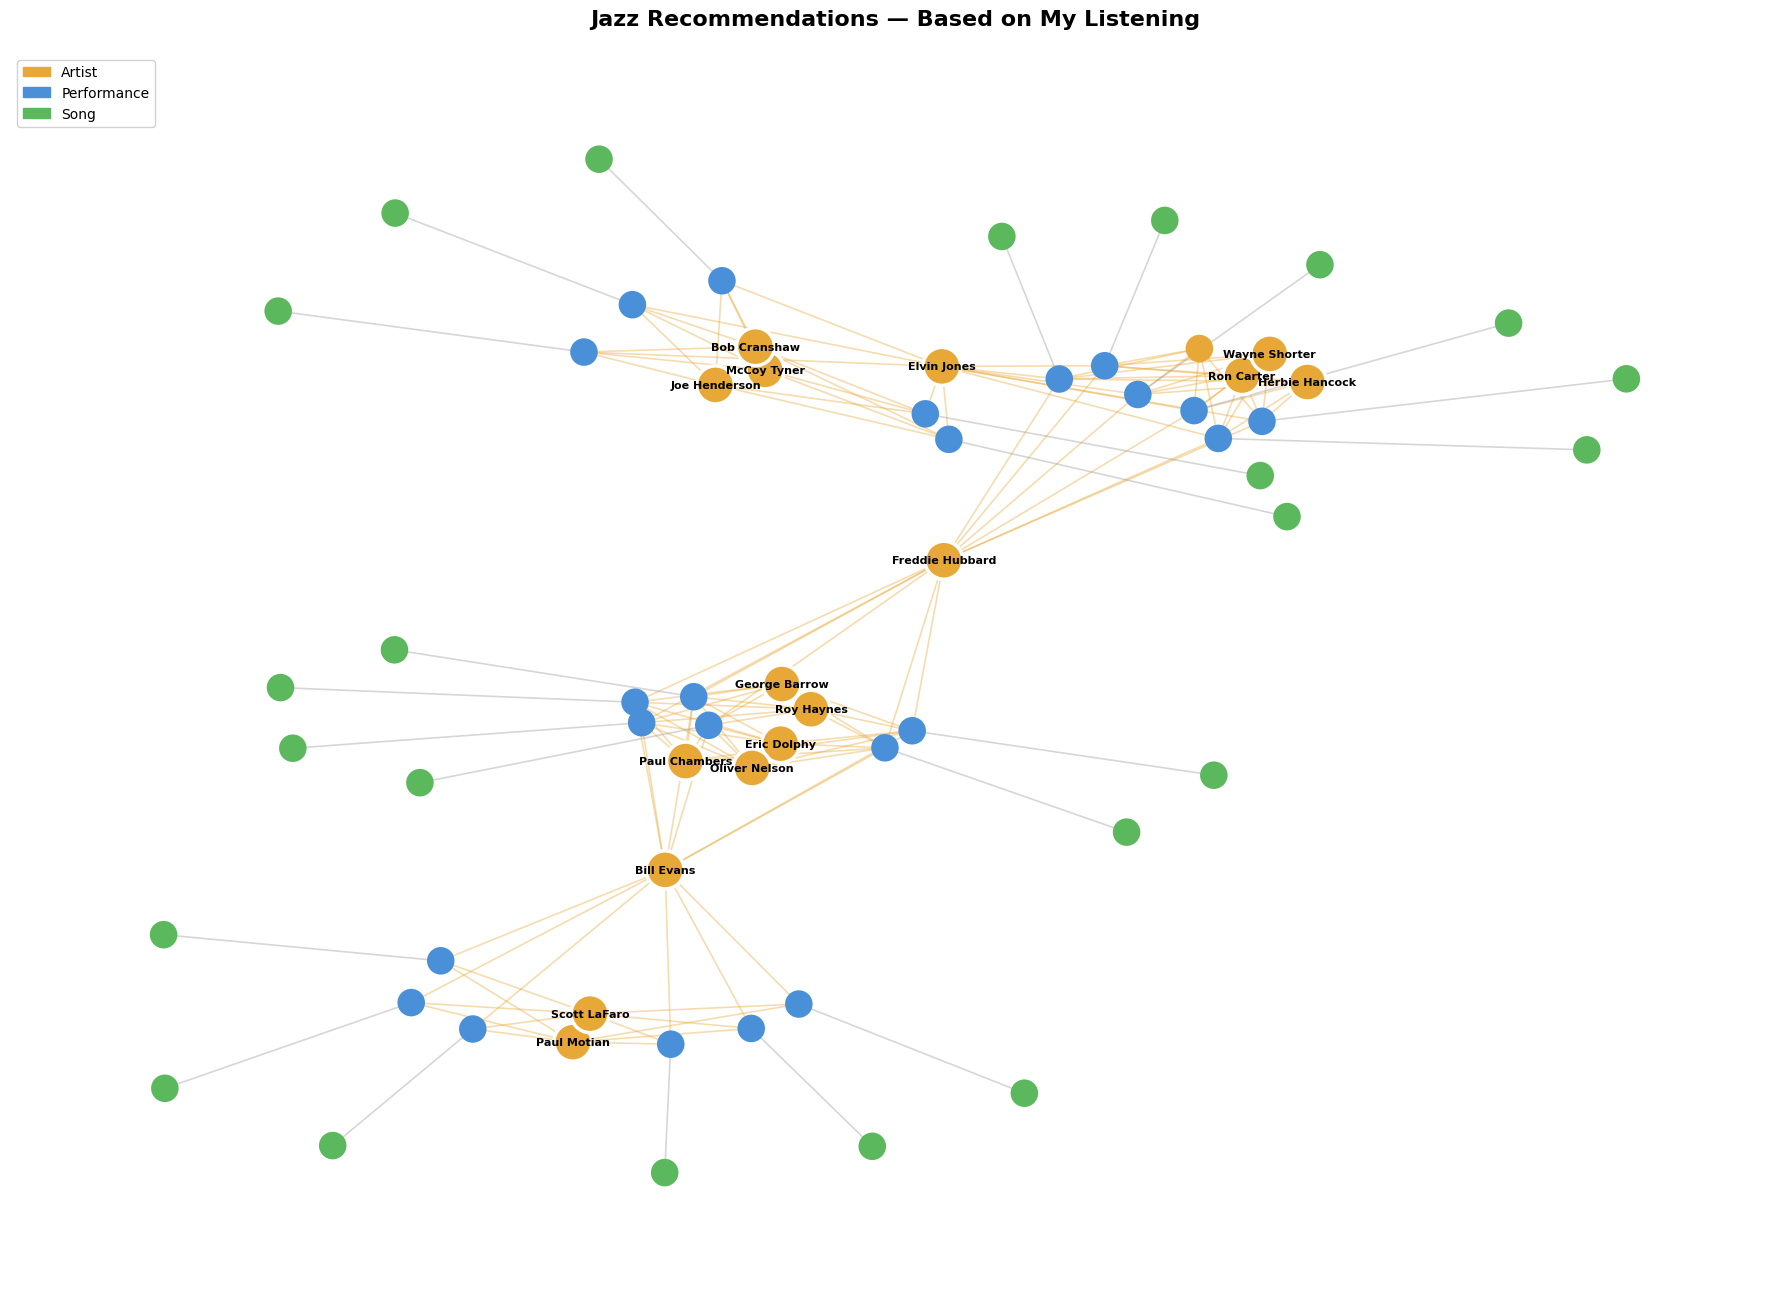

In [ ]:
# Assuming you have local indices for your seed performances
seed_performances = ["artist_0", "artist_7", "artist_8"]
seed_performances = [f'artist_{i}' for i in artist_labels]

node_labels = {
    # "performance": {
    #     42:  "Inner Urge",
    #     107: "Sunday at the Village Vanguard",
    #     203: "The Köln Concert",
    #     18:  "Speak No Evil",
    #     91:  "The Blues and the Abstract Truth",
    # },
    "artist": artist_labels,
    # "performance": performance_labels
}

fig = draw_jazz_graph(
    data=favorites,
    node_labels=node_labels,
    highlight_nodes=seed_performances,
    title="Jazz Recommendations — Based on My Listening",
    figsize=(18, 13),      # poster-friendly
    save_path="poster_graph_.png",
    layout=lambda x: nx.spring_layout(x)
)

## Recommend

In [23]:
from jazz_graph.training.logging import ExperimentLogger, load_embeddings, load_model, find_most_recent_run
from pathlib import Path
import json

from jazz_graph.recommendation.recommender import InferenceRecommender
from jazz_graph.model.model import UnsupervisedJazzModel


checkpoint_path = "/workspace/experiments/2026-04-03_16-48-18_gnn_simCLR_graph_parquet"

with open(Path(checkpoint_path) / 'config.json', 'r') as f:
    run_config = json.loads(f.read())
    nodes_data_path = run_config['data_config'].get('dataset')

experiment_config = {
    'gnn': checkpoint_path,
    'nodes_data': nodes_data_path,
    'recommender_pooling': 'softmax'
}
def get_recommender(checkpoint_path) -> InferenceRecommender:
    class UnsupervisedModelAdapter(torch.nn.Module):
        def __init__(self, model: UnsupervisedJazzModel):
            super().__init__()
            self.model = model

        def __call__(self, x_dict, edge_index_dict, batch):
            return self.model(batch)
    graph_data = make_jazz_graph_with_style_and_edges(JazzDataStore('/workspace/local_data/graph_parquet'))
    model_state = load_model(checkpoint_path)
    model_state = model_state.get('model_state_dict', model_state)
    model = UnsupervisedJazzModel.from_config(run_config)
    model.load_state_dict(model_state)
    model = UnsupervisedModelAdapter(model)
    recommender = InferenceRecommender(model, graph_data, pooling='softmax')
    return recommender

recommender = get_recommender(checkpoint_path)


In [24]:
with torch.no_grad():
    recommender_embeds = recommender.model.model(graph_data)

In [25]:
lookup.lookup_node_index(all_examples)

array([ 1974,  1975,  4388,  4389,  4390,  4391,  4392,  4393,  8797,
        9992,  9993,  9994,  9995,  9996, 15660, 26533, 36261, 63855,
       63856, 71370, 71371, 71372, 71373])

In [ ]:
recommender_embeds['performance'].shape
ids = torch.concat([
    torch.randint(0, recommender_embeds['performance'].size(0), (2000,)),
    torch.tensor(lookup.lookup_node_index(all_examples))
])
sampled_embeds = recommender_embeds['performance'][ids].numpy()

tSNE_embeddings(sampled_embeds[1900:], {}, None, n_components=3, perplexity=3)

In [63]:
def get_recommendations(seeds):
    recommendations, scores, mask = recommender.get_recommendations(seeds)
    return recording_traits.loc[recommendations[~mask]].head(30)


In [192]:
model_recs = [7358212, 5511186, 495915, 9632965, 8585598, 365672, 495912, 495916, 5511185, 495914, 5511184, 495911, 495917, 495913, 7910939, 7358210, 6723097, 9553884, 599006, 7910938, 7910942, 599008, 8387587, 7910937, 7910936, 14350053, 3002492, 2073873, 3282589, 599009, 599005, 5775110, 7910940, 3282592, 2341729, 3282594, 3844937, 365674, 8387585, 14350050, 586536, 1881690, 25842989, 5775108, 7910941, 14350051, 3844938, 365675, 3844942, 2073875, 7040064, 2669490, 3844940, 3844941, 29159281, 6890670, 2074100, 32019189,]
print(recording_traits.loc[model_recs[:30]][['artist', 'album', 'title']].to_markdown())

|   recording_id | artist                   | album                                                            | title                                 |
|---------------:|:-------------------------|:-----------------------------------------------------------------|:--------------------------------------|
|        7358212 | Lee Morgan               | Vol. 3                                                           | Tip-Toeing                            |
|        5511186 | Jackie McLean            | Let Freedom Ring                                                 | Rene                                  |
|         495915 | Thelonious Monk Quintet  | 5 by Monk by 5                                                   | Played Twice (take 2)                 |
|        9632965 | Lee Morgan               | Vol. 3                                                           | Domingo                               |
|        8585598 | Lee Morgan               | Vol. 3                              

In [64]:
all_examples_recs = get_recommendations(all_examples)
all_example_rec_ids = all_examples_recs.index.to_list()
all_examples_with_recs = all_examples + all_example_rec_ids
print(all_examples_recs[['artist', 'album', 'title']].to_markdown())


/workspace/src/jazz_graph/recommendation/recommender.py:178: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  familiar_perf = performance_embed[familiar_nodes]


|   recording_id | artist                              | album                                                                                | title                               |
|---------------:|:------------------------------------|:-------------------------------------------------------------------------------------|:------------------------------------|
|       31487448 | Lucky Thompson                      | Plays Jerome Kern And No More                                                        | Why Do I Love You?                  |
|       19531578 | The Joe Henderson Quintet           | At the Lighthouse - "If You're Not Part of the Solution, You're Part of the Problem" | Caribbean Fire Dance                |
|        1130451 | John Coltrane                       | The Heavyweight Champion: The Complete Atlantic Recordings                           | Giant Steps (take 3) (incomplete)   |
|       15177263 | Joe Henderson Sextet                | The Kicker                       

In [112]:
from torch import rand
import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tSNE_embeddings(
    embeddings: np.ndarray,
    node_labels: dict[int, str],
    figsize: tuple[int, int],
    cutoffs: tuple,
    n_components: int = 2,
    perplexity: int = 30,
    title: str = "Jazz Performance Embedding Space",
    save_path: str = None,
):
    reducer = TSNE(n_components=n_components, random_state=42, perplexity=perplexity)
    embedding_reduced = reducer.fit_transform(embeddings)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d') if n_components == 3 else fig.add_subplot(111)

    LAYERS = [
        (range(0, cutoffs[0]),            "#777777", "Random Sample",   20, 0.4),
        (range(cutoffs[0], cutoffs[1]),   "#E8A838", "Seeds",           40, 0.9),
        (range(cutoffs[1], len(embeddings)), "#4A90D9", "Recommendations", 40, 0.9),
    ]

    for indices, color, label, size, alpha in LAYERS:
        idx = list(indices)
        coords = [embedding_reduced[idx, i] for i in range(n_components)]
        ax.scatter(*coords, c=color, s=size, alpha=alpha, label=label, edgecolors="white", linewidths=0.5)

    # --- Labels for seeds and recommendations ---
    for i in range(cutoffs[0], len(embeddings)):
        label = node_labels.get(i)
        if label:
            ax.annotate(
                label,
                (embedding_reduced[i, 0], embedding_reduced[i, 1]),
                fontsize=7,
                xytext=(5, 5),
                textcoords="offset points",
                color="#222222",
            )

    ax.set_title(title, fontsize=14, pad=15)
    # ax.legend(loc="upper left", framealpha=0.9, markerscale=1.2)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

    if n_components == 2:
        ax.set_xlabel("t-SNE 1", fontsize=9, color="#666666")
        ax.set_ylabel("t-SNE 2", fontsize=9, color="#666666")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)
    else:
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        ax.set_zlabel("t-SNE 3")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return fig

Saved to jazz_performance_embeddings.png


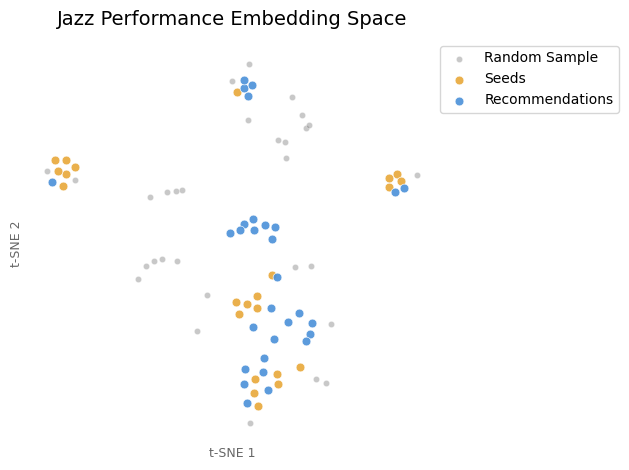

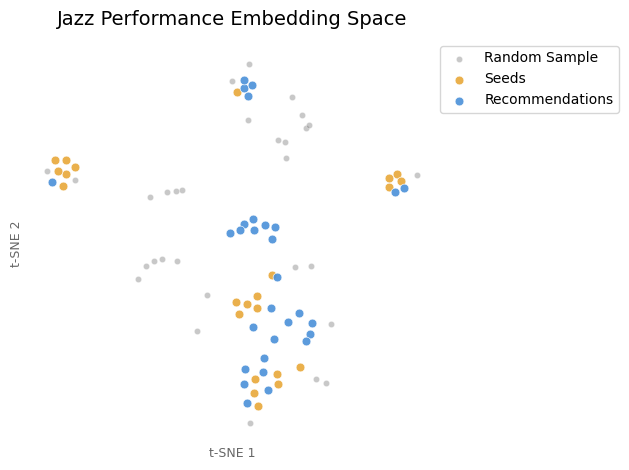

In [113]:
recommender_embeds['performance'].shape
n_random = len(all_example_rec_ids)
ids = torch.concat([
    torch.randint(0, recommender_embeds['performance'].size(0), (n_random,)),
    torch.tensor(lookup.lookup_node_index(all_examples_with_recs))
])
sampled_embeds = recommender_embeds['performance'][ids].numpy()

tSNE_embeddings(sampled_embeds, {}, None, cutoffs=(n_random, n_random + len(all_examples)), n_components=2, perplexity=12, save_path='jazz_performance_embeddings.png')

In [210]:
single_song_rec = get_recommendations([14805309])[['artist', 'album', 'title']] # Isotope
single_song_rec.to_markdown()

/workspace/src/jazz_graph/recommendation/recommender.py:178: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  familiar_perf = performance_embed[familiar_nodes]


'|   recording_id | artist                             | album                           | title                   |\n|---------------:|:-----------------------------------|:--------------------------------|:------------------------|\n|       14805308 | Joe Henderson                      | Inner Urge                      | Inner Urge              |\n|       31407187 | The Don Rendell / Ian Carr Quintet | Shades of Blue                  | Just Blue               |\n|       14805310 | Joe Henderson                      | Inner Urge                      | El Barrio               |\n|       31407190 | The Don Rendell / Ian Carr Quintet | Shades of Blue                  | Blue Doom               |\n|        5895422 | Lester Bowie                       | The Great Pretender             | It’s Howdy Doody Time   |\n|       22843880 | Lester Bowie                       | The Great Pretender             | The Great Pretender     |\n|       31407189 | The Don Rendell / Ian Carr Quintet | Shades 

In [212]:
print(single_song_rec.to_markdown())

|   recording_id | artist                             | album                           | title                   |
|---------------:|:-----------------------------------|:--------------------------------|:------------------------|
|       14805308 | Joe Henderson                      | Inner Urge                      | Inner Urge              |
|       31407187 | The Don Rendell / Ian Carr Quintet | Shades of Blue                  | Just Blue               |
|       14805310 | Joe Henderson                      | Inner Urge                      | El Barrio               |
|       31407190 | The Don Rendell / Ian Carr Quintet | Shades of Blue                  | Blue Doom               |
|        5895422 | Lester Bowie                       | The Great Pretender             | It’s Howdy Doody Time   |
|       22843880 | Lester Bowie                       | The Great Pretender             | The Great Pretender     |
|       31407189 | The Don Rendell / Ian Carr Quintet | Shades of Blue  

In [213]:
recording_traits.loc[14805308 ]

discogs_id                1192202
release_group_id           309832
title                  Inner Urge
album                  Inner Urge
artist              Joe Henderson
release_date           1965-12-31
Name: 14805308, dtype: object

{'performance_121596': 'Just Blue', 'artist_6553': 'Pete La Roca', 'performance_71372': 'El Barrio', 'performance_121594': 'Blue Mosque', 'performance_121599': 'Blue Doom', 'performance_21395': 'Blues Mind Matter', 'performance_71373': 'You Know I Care', 'performance_3965': 'Dahomey Dance', 'performance_37078': 'Oh, How the Ghost Sings', 'performance_121601': 'Big City Strut', 'performance_38622': 'Harmonique', 'performance_121595': 'Latin Blue', 'artist_481': 'McCoy Tyner', 'performance_2561': 'The Prophet', 'performance_71370': 'Inner Urge', 'performance_57711': 'Tan Samfu', 'performance_28127': 'Malagueña', 'artist_882': 'Joe Henderson', 'performance_46266': 'Naïma', 'artist_5740': 'Hamiet Bluiett', 'performance_121600': 'Shades of Blue', 'performance_115064': 'Rain Forest Ripples', 'performance_14672': 'Naima', 'performance_57716': 'Dusk Fire', 'artist_5883': 'Ben Riley', 'performance_21392': 'Summer Nights', 'performance_28132': 'Eiderdown', 'performance_21394': 'Verse', 'performa

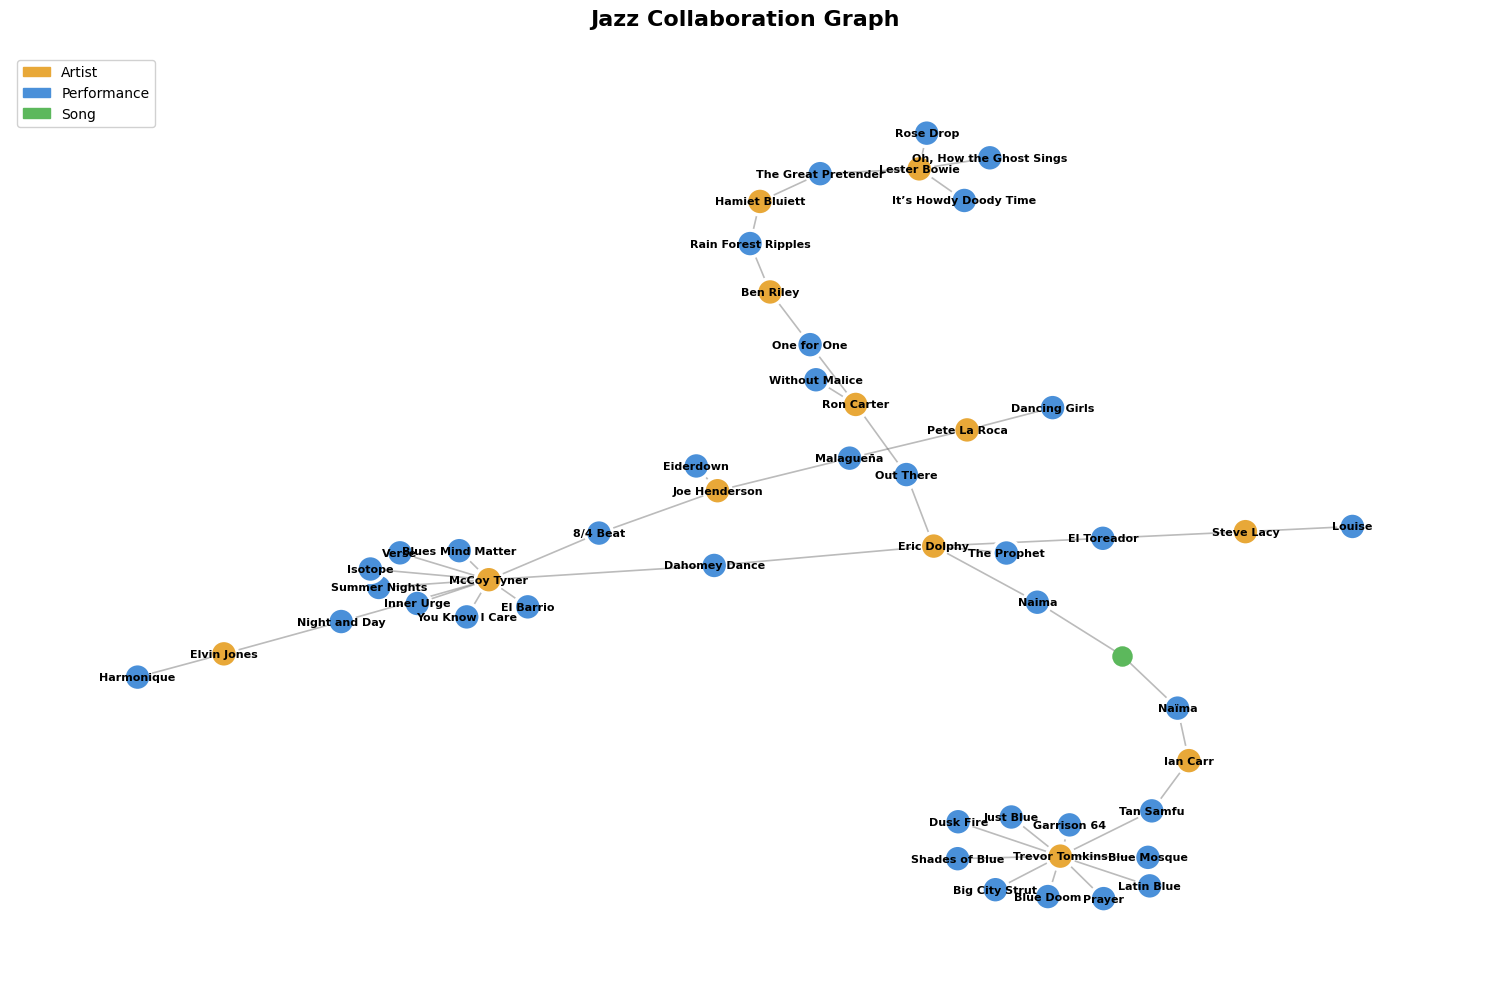

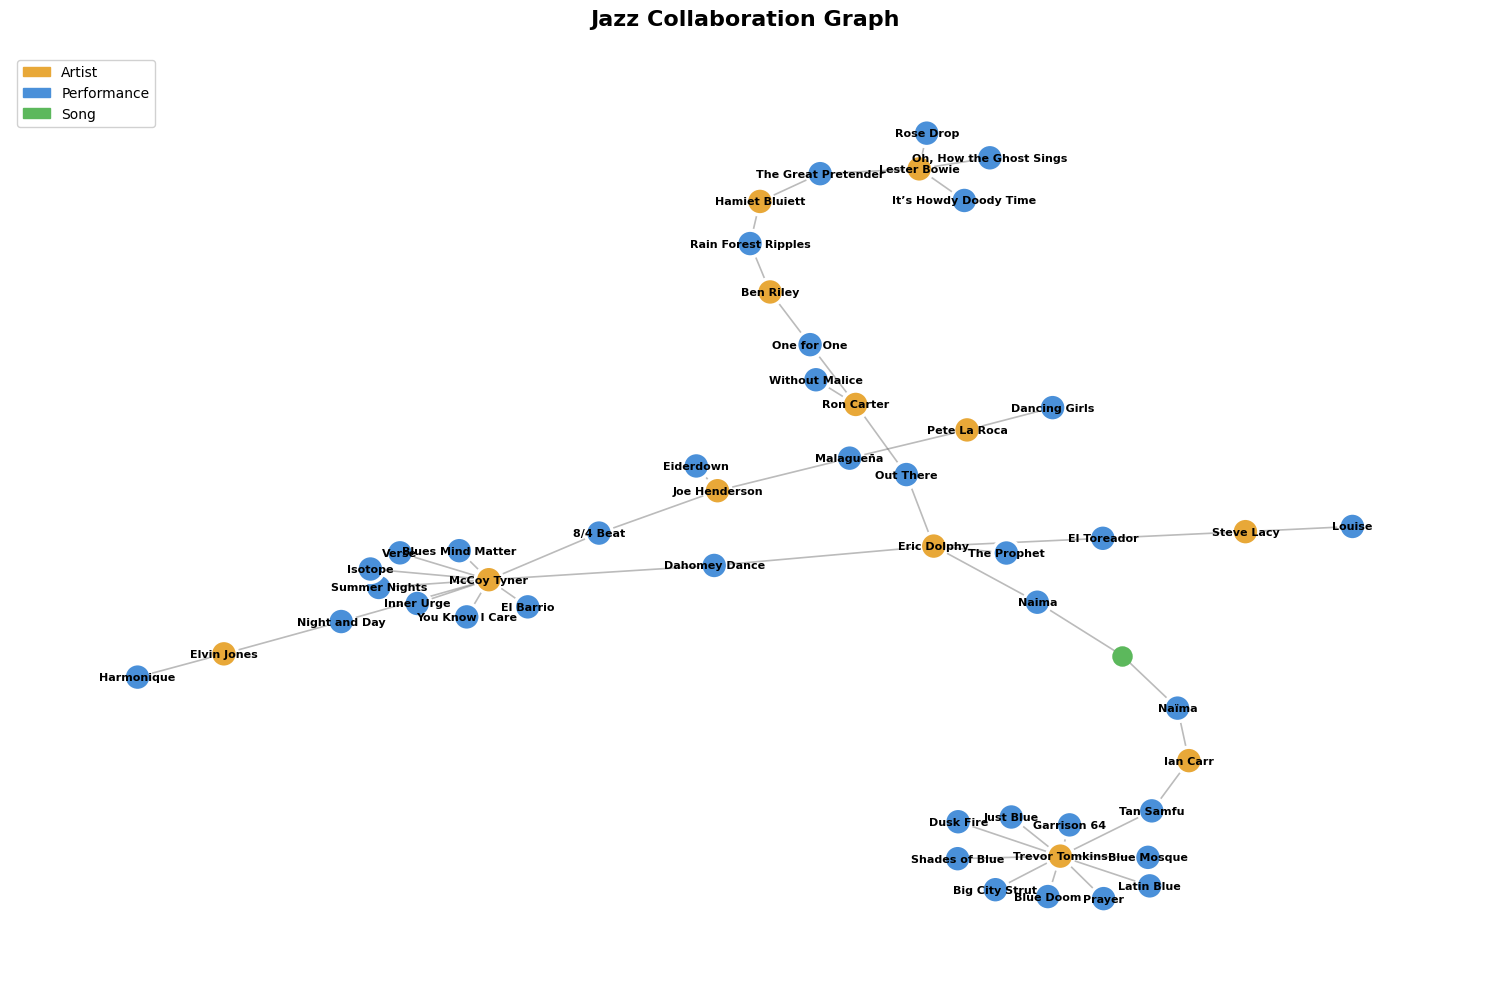

In [262]:
single_song_rec.index
visualize.draw_connections([14805309] + single_song_rec.index.to_list(), figsize=(15, 10), node_size=150, layout=lambda x: nx.spring_layout(x, k=.3, iterations=125))

In [47]:
seen = set()
recs = []
for x in single_song_rec.itertuples():
    if x.album in seen or 'Doody' in x.title:
        continue
    seen.add(x.album)
    if x.artist in seen:
        continue
    seen.add(x.artist)
    recs.append(x.Index)
top_single_recs_plus_isotope = [14805309] + single_song_rec.loc[recs][1:6].index.to_list()

In [112]:

single_rec_node_idx = lookup.lookup_node_index(top_single_recs_plus_isotope)
single_favorites = next(iter(NeighborLoader(graph_data, [10, 4], batch_size=len(single_rec_node_idx), input_nodes=('performance', single_rec_node_idx))))
single_artist_traits = get_artist_traits(query_result, top_single_recs_plus_isotope)

/opt/conda/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: Using 'NeighborSampler' without a 'pyg-lib' installation is deprecated and will be removed soon. Please install 'pyg-lib' for accelerated neighborhood sampling
  neighbor_sampler = NeighborSampler(


In [146]:
single_artist_labels = {'artist': get_artist_labels(single_favorites, single_artist_traits), 'performance': get_performance_labels(single_favorites, recording_traits)}
# single_artist_labels

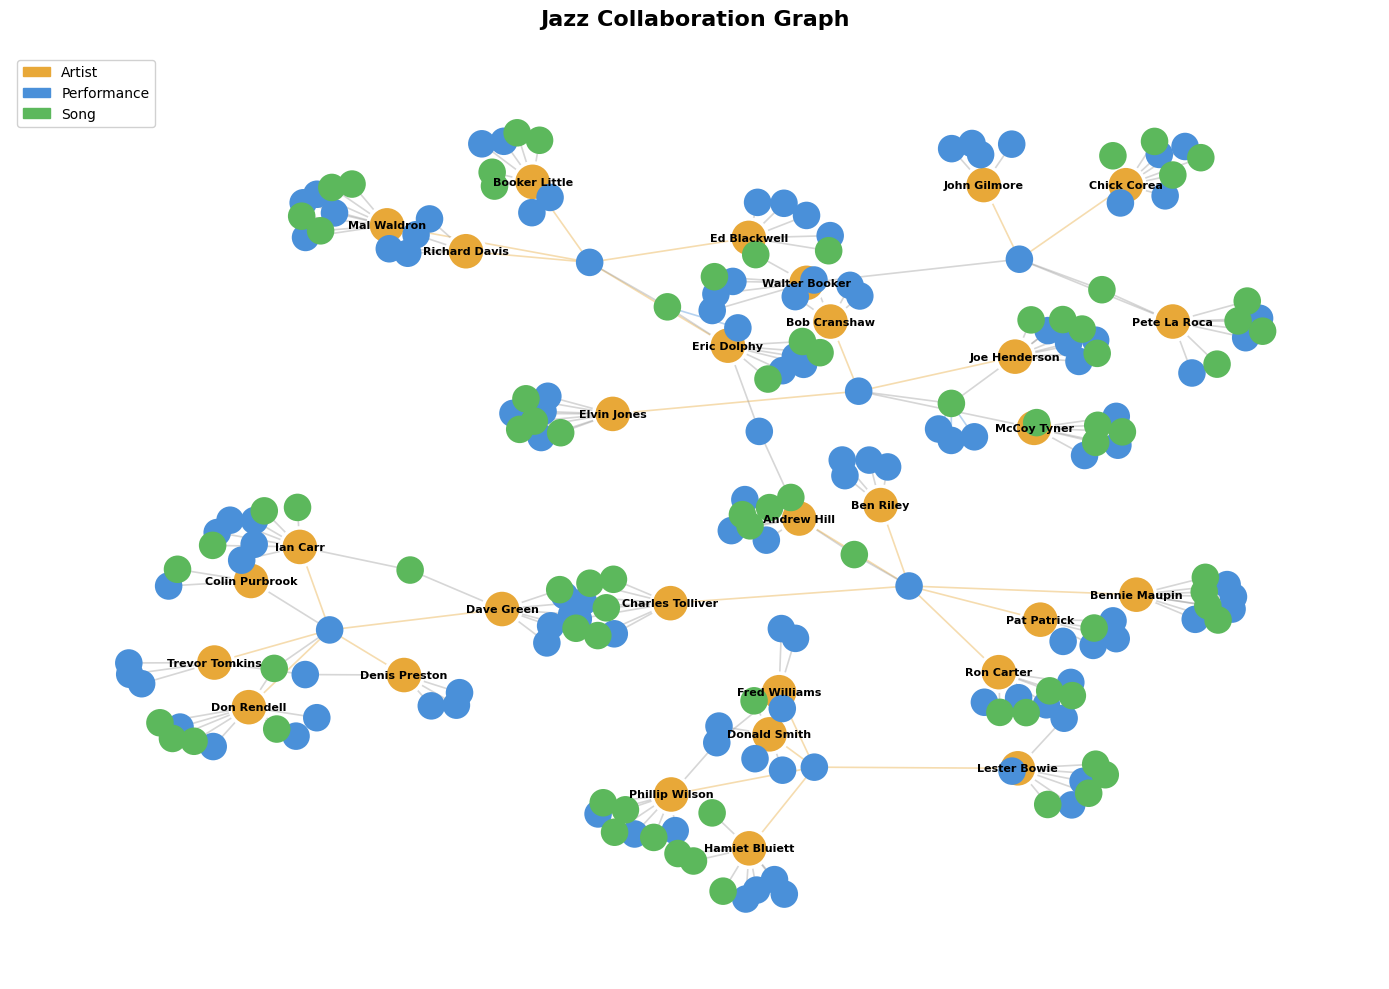

In [115]:
#draw_jazz_graph(single_favorites, single_artist_labels, highlight_nodes=['artist_17', 'artist_11', 'artist_12', 'artist_13', 'artist_26', 'artist_28', 'artist_19', 'artist_0', 'artist_15']);
highlight = [f'performance_{i}' for i in single_artist_labels['performance']]
draw_jazz_graph(single_favorites, single_artist_labels, highlight_nodes=[f'artist_{i}' for i in single_artist_labels['artist']]);


In [184]:
recording_traits.loc[recommendations[~mask][:500]].drop_duplicates('artist').head(30)

,discogs_id,release_group_id,title,album,artist,release_date
recording_id,,,,,,
31487448,2599723,2884988,Why Do I Love You?,Plays Jerome Kern And No More,Lucky Thompson,1963-12-31
19531578,22463683,541701,Caribbean Fire Dance,"At the Lighthouse - ""If You're Not Part of the...",The Joe Henderson Quintet,1970-12-31
1130451,3415863,58170,Giant Steps (take 3) (incomplete),The Heavyweight Champion: The Complete Atlanti...,John Coltrane,1995-08-15
15177263,7025249,1291255,Mo' Joe,The Kicker,Joe Henderson Sextet,1967-12-31
159726,1821735,84933,So What,Miles Davis’ Greatest Hits,Miles Davis,1969-12-31
12317340,4225244,1059125,Some More of Dat,Money in the Pocket,Joe Zawinul,1965-12-31
4389458,1222074,391852,The Profit,It’s Time,"Max Roach, His Chorus and Orchestra",1962-12-31
6663125,4400837,62887,Shifting Down,Hard Driving Jazz,The Cecil Taylor Quintet,1959-12-31
14358520,3645148,1224828,Russ Job,The Trumpet Artistry of Chet Baker,Chet Baker,1955-12-31


In [118]:
single_favorites

HeteroData(
  performance={
    x=[121, 2],
    album_id=[121],
    n_id=[121],
    input_id=[6],
    batch_size=6,
  },
  artist={
    x=[30, 1],
    n_id=[30],
  },
  song={
    x=[80, 1],
    n_id=[80],
  },
  (artist, composed, song)={
    edge_index=[2, 5],
    e_id=[5],
  },
  (artist, performs, performance)={
    edge_index=[2, 33],
    e_id=[33],
  },
  (performance, performing, song)={
    edge_index=[2, 9],
    e_id=[9],
  },
  (song, rev_composed, artist)={
    edge_index=[2, 78],
    e_id=[78],
  },
  (performance, rev_performs, artist)={
    edge_index=[2, 120],
    e_id=[120],
  },
  (song, rev_performing, performance)={
    edge_index=[2, 5],
    e_id=[5],
  },
  (performance, rev_performs, performance)={}
)

In [130]:
single_favorites[('performance', 'rev_performs', 'artist')].edge_index[0]

tensor([ 10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,
         24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  13,  34,  35,  36,
         37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
         51,  52,  53,  54,  55,   2,  56,  57,  58,  59,  60,  61,  62,  63,
         64,  65,  66,  67,  68,  69,  70,  71,  72,   3,  73,  74,  75,  76,
          3,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
         90,  91,  92,  93,  94,  95,  96,  97,  98,  99,  96,  91, 100, 101,
        102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 103, 112, 113, 114,
        115, 116, 117, 118, 119, 108,   5, 120])

array([121596])

In [ ]:
def bfs(graph_data, path, start_node):
    seen_src = set()
    seen_dst = set()
    edge_index = graph_data[path].edge_index
    queue_src = []
    queue_dst = []
    queue_src.append(start_node)
    seen_src.add(start_node)
    current_edge = 'src'
    while queue_src or queue_dst:
        while queue_src:
            cur_node = queue_src.pop(0)
            yield cur_node.item(), path[0]
            # print(edge_index[0] == cur_node)
            # print(edge_index[0])
            new_nodes = edge_index[:, edge_index[0] == cur_node][1]
            # print(new_nodes)
            for node in new_nodes:
                if node in seen_dst:
                    continue
                seen_dst.add(node)
                queue_dst.append(node)
        # print(queue_dst)
        while queue_dst:
            cur_node = queue_dst.pop(0)
            yield cur_node.item(), path[-1]
            new_nodes = edge_index[:, edge_index[1] == cur_node][0]
            for node in new_nodes:
                if node in seen_src:
                    continue
                seen_src.add(node)
                queue_src.append(node)
        # print(queue_src)

isotope = ...
isotope, rendell = lookup.lookup_node_index([14805309, 31407187])
i = 0
for id, type in bfs(graph_data, ('performance', 'rev_performs', 'artist'), torch.tensor(rendell)):

    if type != 'performance':
        continue
    if id == isotope:
        print("Success!!!")
        break
    i += 1
    if i == 10_000:
        break
    # print(recording_traits.loc[id])


In [141]:
graph_data['performance'].x[rendell]

tensor([[    1965, 31407187]])